In [1]:
import os
import glob
import math
import random
import dendropy
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.cluster import KMeans

from Bio import AlignIO, SeqIO, Phylo
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord


In [2]:
ORIGINAL_FA = "/home/yutianc/sim_proj/alignment/H3_human_alignment_dates_fixed.fa"
HA_REF = "/home/yutianc/bjorn/data/flu/reference_HA.fasta"
REP_PREF_1 = "/home/yutianc/sim_proj/dms/replicate-1_prefs.csv"
REP_PREF_2 = "/home/yutianc/sim_proj/dms/replicate-2_prefs.csv"
REP_PREF_3 = "/home/yutianc/sim_proj/dms/replicate-3_prefs.csv"

Pull DMS value from https://www.pnas.org/doi/10.1073/pnas.1806133115#supplementary-materials

In [3]:
# average preference values by replicate
pref1 = pd.read_csv(REP_PREF_1)
pref2 = pd.read_csv(REP_PREF_2)
pref3 = pd.read_csv(REP_PREF_3)

aa_cols = [c for c in pref1.columns if c != 'site']
avg_pref = pref1.copy()
avg_pref[aa_cols] = (pref1[aa_cols] + pref2[aa_cols] + pref3[aa_cols]) / 3

avg_pref.to_csv("/home/yutianc/sim_proj/dms/avg_pref.csv", index=False)

In [4]:
pref = pd.read_csv("/home/yutianc/sim_proj/dms/avg_pref.csv")
ha_ref = SeqIO.read(HA_REF, format="fasta")
align = AlignIO.read(ORIGINAL_FA, format="fasta")

In [5]:
# translate nuc seq in alignment to aa
def translate(seq):
    aa_ls = []
    for i in range(0, len(seq), 3):
        codon = seq[i: i+3]
        try:
            aa = str(Seq(codon).translate(table=1))
        except:
            aa = "X"
        aa_ls.append(aa)
    return aa_ls

aa_dict = {}
aa_dict["ref"] = translate(str(ha_ref.seq))
for s in align:
    aa_dict[s.id] = translate(str(s.seq))


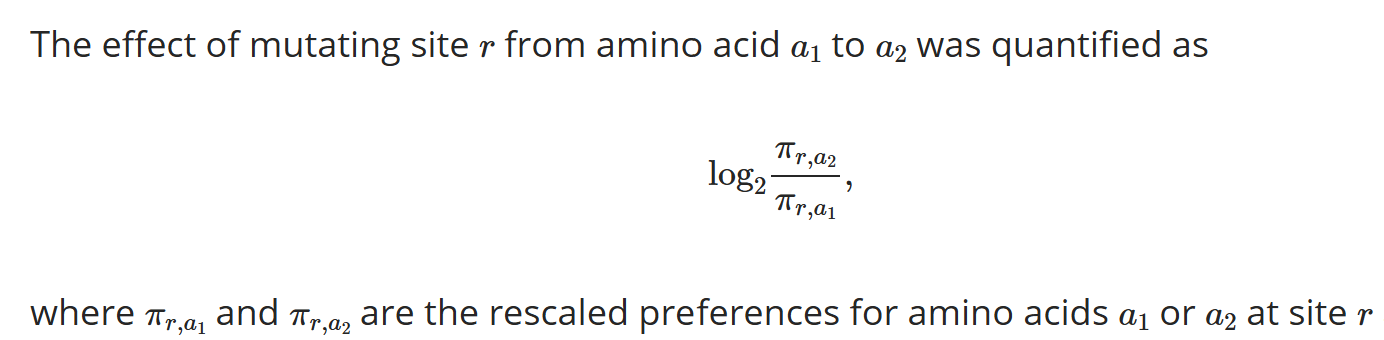

In [6]:
# calculate mutational effect 

AA_COORDS = [1, 566]
site_dms_sum_dict = {}
site_dms_dict = {}

for site in range(AA_COORDS[0], AA_COORDS[-1] + 1):
    wt = aa_dict["ref"][site - 1]
    pi_r_a1 = pref.loc[pref["site"] == site, wt].iloc[0]  
    
    total = 0
    mut_effect_ls = []
    for s in align:
        mutant = aa_dict[str(s.id)][site - 1]
        pi_r_a2 = pref.loc[pref["site"] == site, mutant].iloc[0]  
        mut_effect = math.log2(pi_r_a2 / pi_r_a1)
        total += mut_effect
        mut_effect_ls.append(mut_effect)
    
    site_dms_sum_dict[site] = total  
    site_dms_dict[site] = mut_effect_ls


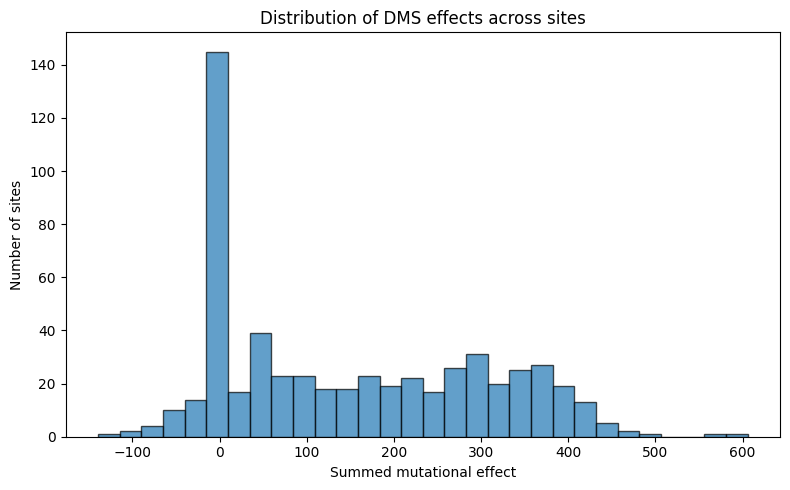

In [7]:
values = list(site_dms_sum_dict.values())

plt.figure(figsize=(8, 5))
plt.hist(values, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Summed mutational effect")
plt.ylabel("Number of sites")
plt.title("Distribution of DMS effects across sites")
plt.tight_layout()
plt.show()

In [8]:
sites = list(site_dms_dict.keys())
X = np.array([site_dms_dict[s] for s in sites])  # shape: (566, 20)

ksums = KMeans(n_clusters=3, random_state=42, n_init="auto")
site_clusters = ksums.fit_predict(X)

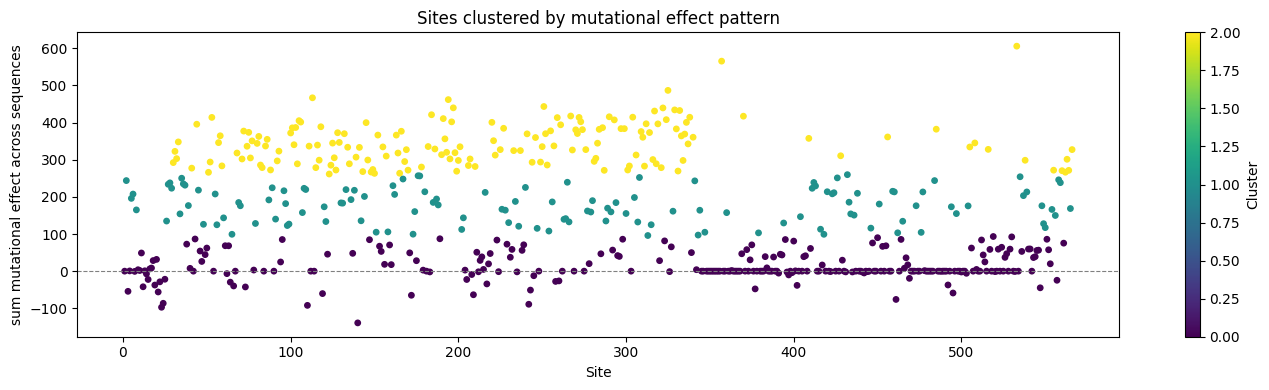

In [9]:
sites = list(site_dms_dict.keys())
X = np.array([site_dms_dict[s] for s in sites])  # shape: (566, 20)

# --- Build a results table ---
results = pd.DataFrame({
    "site": sites,
    "sum_effect": X.sum(axis=1),
    "cluster": site_clusters
})

# Order clusters by sum effect so cluster 0 = most deleterious, etc.
cluster_order = results.groupby("cluster")["sum_effect"].sum().sort_values().index
cluster_map = {old: new for new, old in enumerate(cluster_order)}
results["cluster"] = results["cluster"].map(cluster_map)

# --- 1. Scatter: site vs sum effect, colored by cluster ---
plt.figure(figsize=(14, 4))
scatter = plt.scatter(results["site"], results["sum_effect"], 
                       c=results["cluster"], cmap="viridis", s=15)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel("Site")
plt.ylabel("sum mutational effect across sequences")
plt.title("Sites clustered by mutational effect pattern")
plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

In [10]:
cluster_indices = {
    c: np.where(site_clusters == c)[0].tolist()
    for c in range(3)
}

cluster_sites = {
    c: [sites[i] for i in idxs]
    for c, idxs in cluster_indices.items()
}

In [ ]:
# split the alignment files into 3 subfiles by cluster
align = AlignIO.read(ORIGINAL_FA, "fasta")

n_seqs = len(align)
aln_length = align.get_alignment_length()

for cluster in range(3):
    sites = cluster_sites[cluster]
    nuc_col_idx = []
    col_idx = sorted(s-1 for s in sites) # 0-based idx
    for i in col_idx:
        nuc_col_idx.extend([3 * i, 3 * i + 1, 3 * i + 2])

    new_recs = []
    for rec in align:
        seq = str(rec.seq)
        new_seq = "".join(seq[i] for i in nuc_col_idx)
        assert len(new_seq) == 3*len(sites)
        new_rec = rec[:]
        new_rec.seq = new_rec.seq.__class__(new_seq)
        new_recs.append(new_rec)

    out_path = f"/home/yutianc/sim_proj/cluster_{cluster}_alignment.fasta"
    AlignIO.write(AlignIO.MultipleSeqAlignment(new_recs), out_path, "fasta")

get root sequence for simulation

In [21]:
tree = dendropy.Tree.get(
    path="/home/yutianc/sim_proj/trees/alignment_clusters3_annotated.tree",
    schema="nexus",
    preserve_underscores=True  # important: keeps your taxon names intact, e.g. cds_AAX56510_A
)

tree.write(
    path="/home/yutianc/sim_proj/trees/alignment_clusters3_annotated.nwk",
    schema="newick"
)

print("Converted successfully.")
print(f"Number of leaf nodes: {len(tree.leaf_nodes())}")

Converted successfully.
Number of leaf nodes: 97


run treetime and get the ancestral seq

In [24]:
# Load the tree TreeTime actually wrote out
tree = Phylo.read("/home/yutianc/sim_proj/ancestral_seqs/annotated_tree.nexus", "nexus")
root = tree.root

print("Root node name:", root.name)
print("Root node comment (may contain mutation info):", root.comment)

# Now find the matching sequence in ancestral_sequences.fasta
for record in SeqIO.parse("/home/yutianc/sim_proj/ancestral_seqs/ancestral_sequences.fasta", "fasta"):
    if record.id == root.name:
        root_seq = str(record.seq)
        print(f"\nFound root sequence ({record.id}):")
        print(str(record.seq))
        print(len(str(record.seq)))
        break
else:
    print("No exact match found — root.name may be empty; see fallback below")

# construct root seqs based on cluster sites
root_cluster = {cluster: "" for cluster in range(3)}

# build nucleotide-position sets from amino-acid-position sets
nuc_cluster_sites = {}
for cluster in range(3):
    nuc_sites = set()
    for aa_site in cluster_sites[cluster]:
        nuc_start = 3 * (aa_site - 1) + 1  # 1-indexed first nt of this codon
        nuc_sites.update([nuc_start, nuc_start + 1, nuc_start + 2])
    nuc_cluster_sites[cluster] = nuc_sites

for i in range(len(root_seq)):
    for cluster in range(3):
        if i + 1 in nuc_cluster_sites[cluster]:
            root_cluster[cluster] += root_seq[i]
            break

root_cluster

Root node name: NODE_0000000
Root node comment (may contain mutation info): None

Found root sequence (NODE_0000000):
ATGAAGACCATCATTGCTTTGAGCTACATTTTCTGTCTGGCTCTCGGCCAAGACCTTCCAGGAAATGACAACAGCACAGCAACGCTGTGCCTGGGACATCATGCGGTGCCAAACGGAACACTAGTGAAAACAATCACAAATGATCAGATTGAAGTGACTAATGCTACTGAGCTAGTTCAGAGCTCCTCAACGGGGAAAATATGCAACAATCCTCATCGAATCCTTGATGGAATAGACTGCACACTGATAGATGCTCTATTGGGGGACCCTCATTGTGATGTTTTTCAAAATGAGACATGGGACCTTTTCGTTGAACGCAGCAAAGCTTTCAGCAACTGTTACCCTTATGATGTGCCAGATTATGCCTCCCTTAGGTCACTAGTTGCCTCGTCAGGCACTCTGGAGTTTATCACTGAGGGTTTCACTTGGACTGGGGTCACTCAGAATGGGGGAAGCAATGCTTGCAAAAGGGGACCTGGTAGCGGTTTTTTCAGTAGACTGAACTGGTTGACCAAATCAGGAAGCACATATCCAGTGCTGAACGTGACTATGCCAAACAATGACAATTTTGACAAACTATACATTTGGGGGGTTCACCACCCGAGCACGAACCAAGAACAAACCAGCCTGTATGTTCAAGCATCAGGGAGAGTCACAGTCTCTACCAGGAGAAGCCAGCAAACTATAATCCCGAATATCGGGTCCAGACCCTGGGTAAGGGGTCTGTCTAGTAGAATAAGCATCTATTGGACAATAGTTAAGCCGGGAGACGTACTGGTAATTAATAGTAATGGGAACCTAATCGCTCCTCGGGGTTATTTCAAAATGCGCACTGGGAAAAGCTCAATAATGAGGTCAGATGCACCTATTGATACCTGTATT

{0: 'ATGACCATCTTGTACATTTTCTGTCTGGCTCTCGGCCAAGACCTTCCAGGAAATGACAACAGCACACATACAGTGACAAATGATCAGATTAATAGCTCCTCAACGGGGAAAATACGAATAGACGATCCTGTTTTTAGCTTCAACTACCCAGCCATCGGTACTAATAAACCTGGTACCAAAAGCGTGAACACTAATAACCAAACCAGCGTTCAAGCATCAAGAGTCACAAGGAGAATACCGAATTCCAGAGTACTGTCTAGAATCGGAGTAGTAAATAGTAACGCTAAAACTGGGAGGGCAACCTCTATCAGCGTAGCAAAGCAAGTAAAACAAAGAGGCCTATTCGGTGCAATAGCAGGTTTCATAGAAGGTTGGGGAATGATAGACGGTTGGTACGGTTTCCATCAAAATTCTGAGGGCACAGGACAAGCAGCAGATCTTAAAAGCACTCAAGCAGCCATCGACCAAATCAATAAATTGAACAGGATCGAGAAGAACAAATTCCAAGAATTCTCAGAAGTAGAAAGAATTCTCAAAGTTGAAGACGATTGGTACAATGCGGAGCTTCTTGTCGCTGAGAATCAAACAATTGACGACTCGAACAAGCTGAAAACAAGGAGGCAACTGAGGAATGCTGACATGGGCAATGGTTGCTTCTACCACAAATGTGACAACGCTTGCGAGTCAAGAAATGGGACTTATGACGTATACGACGAAGCATTAAACAACCGGCAGATCAAAGGTGTTGAACTGAAGTCTGGATACAAAGACTGGATCCTGATTTTTTGCTTTTTGCTTTGTGTTGTTTTGTTCATCATGTGGAGAAGG',
 1: 'TGCCTGCATGGACTAACAATCGTGACTGAGCTATGCCATATCCTTGATGGATGCACACTGGCTCTAGATTGGGACCTTTTCGAACGCAGCTGTTATGATGTGAGGCTAGTTGCCGGCGAGTTCTGGGGGGTCAGCTTTTTCAGACTGTGGACACCAGTG

In [25]:
for c in root_cluster.keys():
    print(len(root_cluster[c]))

828
408
462


In [ ]:

def build_nuc_order(cluster_sites, n_clusters=3):
    """
    For each cluster, return the ordered list of nucleotide positions
    (1-indexed, in the ORIGINAL full-length sequence) that make up that
    partition -- in the SAME order used when the ancestral sequence for
    that partition was concatenated (sorted AA site order).
    """
    partition_nuc_order = {}  # cluster -> list of original nt positions, in partition order
    for cluster in range(n_clusters):
        aa_sites_sorted = sorted(cluster_sites[cluster])
        nuc_order = []
        for aa_site in aa_sites_sorted:
            nuc_start = 3 * (aa_site - 1) + 1  # 1-indexed first nt of this codon
            nuc_order.extend([nuc_start, nuc_start + 1, nuc_start + 2])
        partition_nuc_order[cluster] = nuc_order
    return partition_nuc_order


def map_seq_to_original_order(sim_seq, partition_nuc_order, partition_lengths, n_clusters=3):
    """
    sim_seq: the simulated sequence string, ordered as
             partition1 (len0 nt) + partition2 (len1 nt) + partition3 (len2 nt)...
    partition_nuc_order: output of build_nuc_order()
    partition_lengths: list of nt lengths per partition, e.g. [828, 408, 462]

    Returns: dict {original_nt_position (1-indexed): base}
    """
    assert len(sim_seq) == sum(partition_lengths), \
        f"seq length {len(sim_seq)} != sum of partition lengths {sum(partition_lengths)}"

    original_pos_to_base = {}
    offset = 0
    for cluster in range(n_clusters):
        plen = partition_lengths[cluster]
        chunk = sim_seq[offset: offset + plen]
        nuc_order = partition_nuc_order[cluster]
        assert len(chunk) == len(nuc_order), \
            f"cluster {cluster}: chunk length {len(chunk)} != nuc_order length {len(nuc_order)}"

        for base, orig_pos in zip(chunk, nuc_order):
            original_pos_to_base[orig_pos] = base

        offset += plen

    return original_pos_to_base


def reconstruct_full_sequence(original_pos_to_base, total_length):
    """
    Reassemble the full-length sequence string in original site order (1..total_length).
    Raises if any position is missing (coverage gap) -- helps catch bugs early.
    """
    missing = [p for p in range(1, total_length + 1) if p not in original_pos_to_base]
    if missing:
        raise ValueError(f"Missing {len(missing)} positions, e.g. {missing[:10]}")

    return "".join(original_pos_to_base[p] for p in range(1, total_length + 1))


# ---------------------------------------------------------
# Usage
# ---------------------------------------------------------

partition_lengths = [828, 408, 462]   # nt lengths of partition 1, 2, 3 (must match XML)
total_length = sum(partition_lengths)  # 1698

partition_nuc_order = build_nuc_order(cluster_sites)

sim_seq_dir = "/home/yutianc/sim_proj/sim_seqs/cluster/"

for seq in os.listdir(sim_seq_dir):
    reordered_records = []

    seq_path = os.path.join(sim_seq_dir, seq)
    if os.path.isfile(seq_path):
        for record in SeqIO.parse(seq_path, "fasta"):
            sim_seq = str(record.seq)
            pos_to_base = map_seq_to_original_order(sim_seq, partition_nuc_order, partition_lengths)
            full_seq = reconstruct_full_sequence(pos_to_base, total_length)

            reordered_records.append(SeqRecord(Seq(full_seq), id=record.id, description=""))

        base, ext = os.path.splitext(seq_path)
        out_path = f"{base}_reordered{ext}"

        SeqIO.write(reordered_records, out_path, "fasta")
        print(f"Wrote {len(reordered_records)} reordered sequences to {out_path}")

1698


AssertionError: cluster 0: chunk length 828 != nuc_order length 798

For each of the three groups, construct a matrix of probabilities of one amino acid changing to another as a ratio of the DMS value measuring replication. We will use this for the next iteration of the model where the rates will be parameterized directly in terms of the DMS values.

In [11]:
def build_effect_matrix(aa_cols, pref, site):
    matrix = pd.DataFrame(0.0, index=aa_cols, columns=aa_cols)
    for wt in aa_cols:
        pi_r_a1 = pref.loc[pref["site"] == site, wt].iloc[0]  
        for mut in aa_cols:
            pi_r_a2 = pref.loc[pref["site"] == site, mut].iloc[0]  
            mutational_effect = pi_r_a2 / pi_r_a1 # without log2 to avoid negative values
            matrix.loc[wt, mut] = mutational_effect # shape: (20, 20)
    return matrix

def build_prob_matrix(effect_matrix):
    row_sum = effect_matrix.sum(axis=1, keepdims=True) 
    prob_matrix = effect_matrix / row_sum # normalize
    return prob_matrix

aa_cols = [col for col in pref.columns if col != "site"]
for cluster in cluster_sites.keys():
    sites = cluster_sites[cluster]
    site_metrices = [] # shape: (n_sites, 20, 20)
    for site in sites:
        matrix = build_effect_matrix(aa_cols, pref, site)
        site_metrices.append(matrix)
        
    stacked_site_metrics = np.stack([m.values for m in site_metrices])
    avg_effect_metrix = np.mean(stacked_site_metrics, axis=0) # average by site
    prob_matrix = build_prob_matrix(avg_effect_metrix)
    prob_df = pd.DataFrame(prob_matrix, index=aa_cols, columns=aa_cols)
    prob_df.to_csv(f"/home/yutianc/sim_proj/dms/aa_prob_matrix_cluster_{cluster}.csv", index=aa_cols)


In [ ]:
# codon table without stopping codon
CODON_TABLE = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",

    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S",
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",

    "TAT": "Y", "TAC": "Y", 
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",

    "TGT": "C", "TGC": "C", "TGG": "W",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AGT": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}

aa_to_codons = {}
for codon, aa in CODON_TABLE.items():
    if aa not in list(aa_to_codons.keys()):
        aa_to_codons[aa] = [codon]
    else:
        aa_to_codons[aa].append(codon)

In [14]:
def cal_hamming_dist(codon1, codon2):
    return sum(c1 != c2 for c1, c2 in zip(codon1, codon2))

def renormalize(matrix):
    # update the codon probability matrix according to YANG model
    new_matrix = matrix.copy()

    for wt_codon in new_matrix.index:
        for mut_codon in new_matrix.columns:
            hamming_dist = cal_hamming_dist(wt_codon, mut_codon)
            if hamming_dist != 1:
                new_matrix.loc[wt_codon, mut_codon] = 0

    # renormalize
    row_sums = new_matrix.sum(axis=1)
    new_matrix = new_matrix.div(row_sums, axis=0)
    return new_matrix


codons = list(CODON_TABLE.keys())

for cluster in list(cluster_sites.keys()):
    aa_matrix = pd.read_csv(f"/home/yutianc/sim_proj/dms/aa_prob_matrix_cluster_{cluster}.csv", index_col=0)
    codon_matrix = pd.DataFrame(0.0, index=codons, columns=codons)

    for wt in aa_cols:
        wt_codons = aa_to_codons[wt]
        for mut in aa_cols:
            aa_prob = aa_matrix.loc[wt, mut]
            mut_codons = aa_to_codons[mut]
            prob_per_codon = aa_prob / len(mut_codons)

            for wt_codon in wt_codons:
                for mut_codon in mut_codons:
                    codon_matrix.loc[wt_codon, mut_codon] = prob_per_codon
    
    codon_matrix = renormalize(codon_matrix)
    codon_matrix.to_csv(f"/home/yutianc/sim_proj/dms/codon_prob_matrix_cluster_{cluster}.csv")

Estimate the parameters (omega, kappa, mu) using log linear model

log(q_ij) = log(μ) + I_transition · log(κ) + I_nonsyn · log(ω) + log(π_j), where q_ij is the codon probability matrix, π_j is the equilibrium freq of the target codon with I_transition and I_nonsyn being the indicator of transition and nonsynoymous mutation.

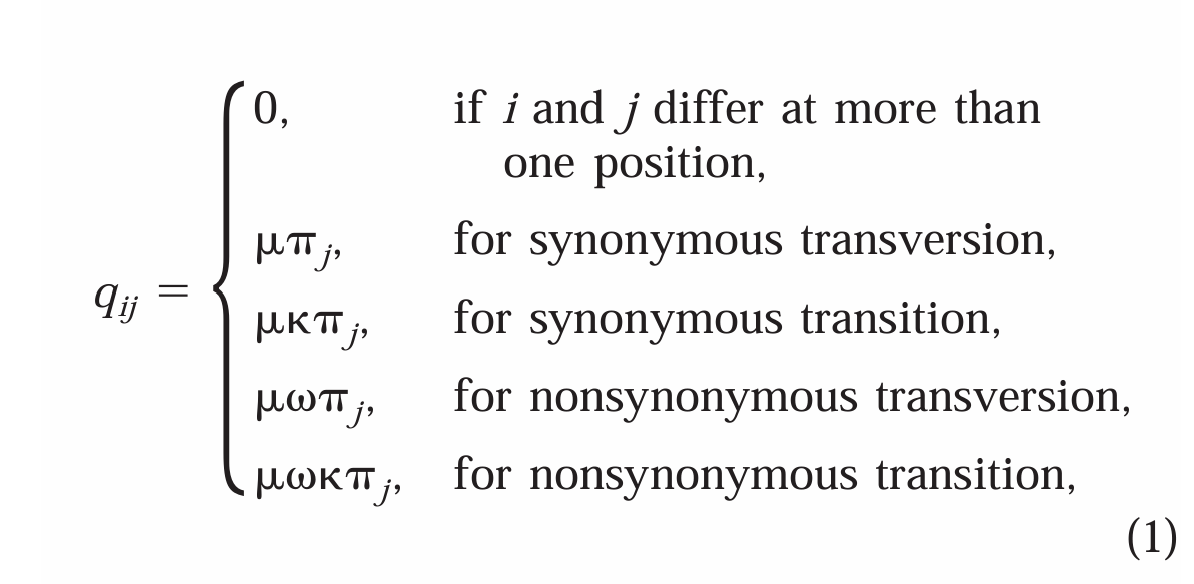

In [21]:
def is_nonsyn(codon1, codon2):
    return True if CODON_TABLE[codon1] == CODON_TABLE[codon2] else False

def is_transition(nuc1, nuc2):
    # transition: purine swaps for a purine, or a pyrimidine swaps for a pyrimidine
    PURINES = {"A", "G"}
    PYRIMIDINES = {"C", "T"}
    return (nuc1 in PURINES and nuc2 in PURINES) or (nuc1 in PYRIMIDINES and nuc2 in PYRIMIDINES)

def get_diff_nuc(codon1, codon2):
    diff_nuc_idx = [i for i in range(3) if codon1[i] != codon2[i]]
    assert len(diff_nuc_idx) == 1
    return codon1[diff_nuc_idx[0]], codon2[diff_nuc_idx[0]]

def estimate(matrix, pi):
    codons = list(matrix.index)
    x, y, offset = [], [], []
    
    for ci, cj in product(codons, codons):
        if ci == cj or matrix.loc[ci, cj] == 0: # only consider the mutation with one nuc changing
            continue

        i_nonsyn = int(is_nonsyn(ci, cj))
        nuc1, nuc2 = get_diff_nuc(ci, cj)
        i_transition = int(is_transition(nuc1, nuc2))
        q_ij = matrix.loc[ci, cj]
        pi_j = pi[cj]

        # log(q_ij) = log(μ) + I_transition · log(κ) + I_nonsyn · log(ω) + log(π_j) -> y=ax+b
        y.append(np.log(q_ij))
        x.append([1.0, i_transition, i_nonsyn])
        offset.append(np.log(pi_j))

    X, Y, OFFSET = np.array(x), np.array(y), np.array(offset)
    mdl = sm.GLM(Y, X, family=sm.families.Gaussian(), offset=OFFSET)
    res = mdl.fit()
    log_mu, log_kappa, log_omega = res.params
    return math.exp(log_mu), math.exp(log_kappa), math.exp(log_omega)

In [23]:
# assume uniform distn for pi_j
pi = {codon:1 / len(CODON_TABLE) for codon in CODON_TABLE.keys()}

for cluster in range(3):
    matrix = pd.read_csv(f"/home/yutianc/sim_proj/dms/codon_prob_matrix_cluster_{cluster}.csv", index_col=0)
    mu, kappa, omega = estimate(matrix, pi)
    print(f"cluster{cluster} - mu: {mu}, kappa: {kappa}, omega: {omega}")

cluster0 - mu: 7.165342537607588, kappa: 1.002255752195922, omega: 0.5234388503992878
cluster1 - mu: 7.2477120865734666, kappa: 1.005119056314393, omega: 0.4912878201514216
cluster2 - mu: 7.1288295561982125, kappa: 1.0059057303530297, omega: 0.5277678896959855
